# ARCH Technologies Internship - Task 4-Facial Emotion Recognition
 Build a facial emotion recognition system that can identify emotions such as happy,
 sad, angry, or surprised from images of human faces. Use a labeled dataset of facial
 expressions, preprocess the images, train a convolutional neural network (CNN),
 and evaluate the model’s accuracy in classifying emotions. Dataset to use: FER
2013 dataset

# 1) Imports and configuration

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.regularizers import l1,l2
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# 2) Data Loading and Exploration

In [ ]:
# Step 1 — Upload & extract ZIP (Colab)
from google.colab import files
import os, zipfile

# Upload file (this will open upload dialog in Colab)
uploaded = files.upload()

# Get uploaded zip file name
zip_path = list(uploaded.keys())[0]   # automatically detects your uploaded ZIP file
extract_path = "/content/emotion_data"

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")
print("Extracted folders:")
for root, dirs, files in os.walk(extract_path):
    for d in dirs:
        print("📁", os.path.join(root, d))


Saving Emotion Detection.zip to Emotion Detection (1).zip
Extracted successfully!
Extracted folders:
📁 /content/emotion_data/dataset
📁 /content/emotion_data/dataset/train
📁 /content/emotion_data/dataset/single_prediction
📁 /content/emotion_data/dataset/test
📁 /content/emotion_data/dataset/train/fear
📁 /content/emotion_data/dataset/train/angry
📁 /content/emotion_data/dataset/train/neutral
📁 /content/emotion_data/dataset/train/surprise
📁 /content/emotion_data/dataset/train/happy
📁 /content/emotion_data/dataset/train/disgust
📁 /content/emotion_data/dataset/train/sad
📁 /content/emotion_data/dataset/test/fear
📁 /content/emotion_data/dataset/test/angry
📁 /content/emotion_data/dataset/test/neutral
📁 /content/emotion_data/dataset/test/surprise
📁 /content/emotion_data/dataset/test/happy
📁 /content/emotion_data/dataset/test/disgust
📁 /content/emotion_data/dataset/test/sad


In [ ]:
# Step 2 — Define correct dataset paths
train_path = "/content/emotion_data/dataset/train"
test_path  = "/content/emotion_data/dataset/test"

print("Training path:", train_path)
print("Testing path:", test_path)


Training path: /content/emotion_data/dataset/train
Testing path: /content/emotion_data/dataset/test


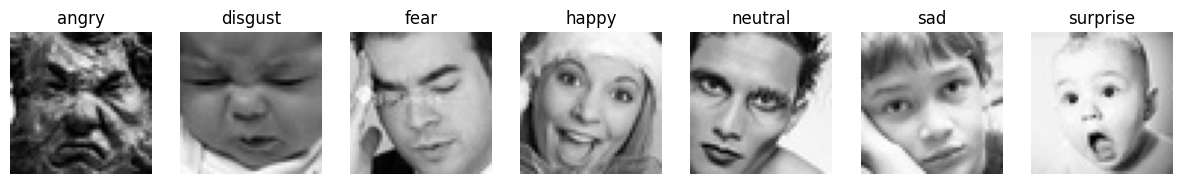

In [ ]:
# Visualize one sample per class (48x48 grayscale)
from tensorflow.keras.preprocessing.image import load_img, img_to_array
IMG_SIZE = (48, 48)

# Get class folders from train_path and sort them numerically if they are numeric strings.
class_folders = sorted(os.listdir(train_path), key=lambda x: int(x) if x.isdigit() else x)

plt.figure(figsize=(15, 3))
for idx, cls in enumerate(class_folders):
    cls_dir = os.path.join(train_path, cls)
    files = os.listdir(cls_dir)
    if not files:
        continue
    img_path = os.path.join(cls_dir, files[0])
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='grayscale')
    arr = img_to_array(img).squeeze()
    plt.subplot(1, len(class_folders), idx+1)
    plt.imshow(arr, cmap='gray')
    plt.title(cls)
    plt.axis('off')
plt.show()


# 3) Data Preprocessing

In [ ]:
# Step 3 — Generators (training / validation / test)
BATCH_SIZE = 32
IMG_SIZE = (48, 48)          # height, width
INPUT_SHAPE = (48, 48, 1)    # grayscale channel

# Training data generator with augmentation and a validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest',
    validation_split=0.2
)

# Test/validation generator should only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

# IMPORTANT: use same class order for both generators (enforces consistent mapping)
# We already created class_folders above; ensure it's the list you want.
print("Using class order:", class_folders)

train_generator = train_datagen.flow_from_directory(
    directory=train_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    classes=class_folders,         # force this order
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    directory=train_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    classes=class_folders,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Test generator: set shuffle=False so predictions align with test_generator.classes
test_generator = test_datagen.flow_from_directory(
    directory=test_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    classes=class_folders,
    class_mode='categorical',
    shuffle=False
)

# Print mapping
print("class_indices:", train_generator.class_indices)


Using class order: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
class_indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


# 4) Model Architecture

In [ ]:

model = Sequential()

# Conv Block 1
model.add(Conv2D(64, (3,3), padding='same', activation='relu',input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Conv Block 2
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Conv Block 3
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Conv Block 4
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))

# Conv Block 5
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(7, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 4,049,671 (15.45 MB)

 Trainable params: 4,046,215 (15.44 MB)

 Non-trainable params: 3,456 (13.50 KB)

# 5) Callbacks and training

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=callbacks
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


718/718 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.1972 - loss: 2.3187 - val_accuracy: 0.2707 - val_loss: 2.0027 - learning_rate: 1.0000e-04
Epoch 2/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.2777 - loss: 2.0020 - val_accuracy: 0.3304 - val_loss: 1.8161 - learning_rate: 1.0000e-04
Epoch 3/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3415 - loss: 1.8521 - val_accuracy: 0.3134 - val_loss: 3.0272 - learning_rate: 1.0000e-04
Epoch 4/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3902 - loss: 1.7074 - val_accuracy: 0.3893 - val_loss: 1.6811 - learning_rate: 1.0000e-04
Epoch 5/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.4202 - loss: 1.6144 - val_accuracy: 0.4454 - val_loss: 1.5398 - learning_rate: 1.0000e-04
Epoch 6/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.4538 - loss: 1.5329 - val_accuracy: 0.4431 - val_loss: 1.5235 - learning_rate: 1.0000e-04
Epoch 7/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - a

# 6) Evaluate on validation set (best model saved as Uzair_Emotion_model_final.h5)

In [ ]:
# Step 7 — Save final model and (optionally) download in Colab
model.save('Uzair_Emotion_model_final.h5')
from google.colab import files
files.download('Uzair_Emotion_model_final.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 7) Evaluate on test set and confusion matrix


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6010 - loss: 1.1812
Test loss: 1.0557, Test accuracy: 0.6442
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


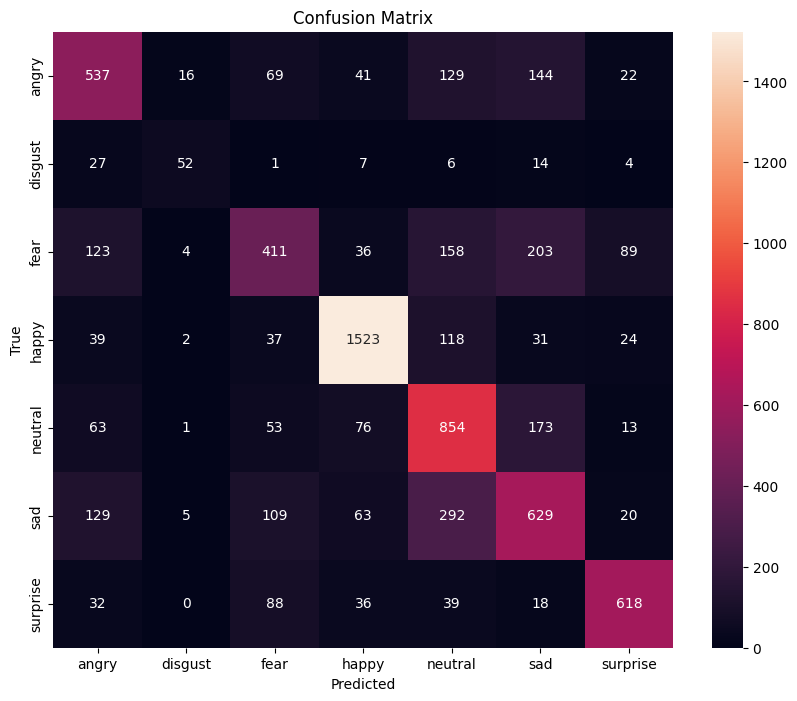

Classification Report:
              precision    recall  f1-score   support

       angry       0.57      0.56      0.56       958
     disgust       0.65      0.47      0.54       111
        fear       0.54      0.40      0.46      1024
       happy       0.85      0.86      0.86      1774
     neutral       0.54      0.69      0.60      1233
         sad       0.52      0.50      0.51      1247
    surprise       0.78      0.74      0.76       831

    accuracy                           0.64      7178
   macro avg       0.63      0.60      0.61      7178
weighted avg       0.65      0.64      0.64      7178



In [ ]:

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

# Predictions — ensure test_generator.shuffle=False so order matches
Y_pred = model.predict(test_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


# 8) Plot Accuracy and Loss

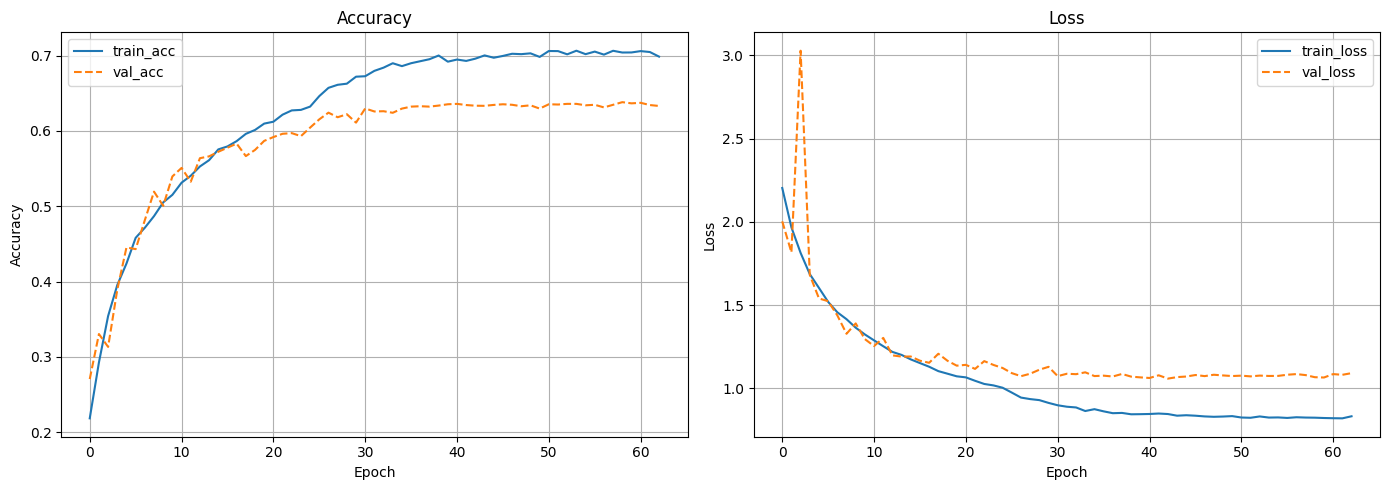

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc', linestyle='--')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss', linestyle='--')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# 10) Single image prediction + show probabilities and image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


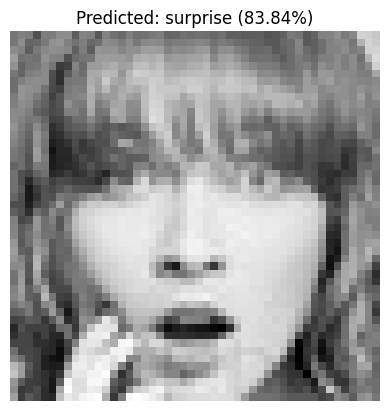

Class probabilities:
angry: 0.39%
disgust: 0.02%
fear: 10.64%
happy: 4.48%
neutral: 0.31%
sad: 0.32%
surprise: 83.84%


In [ ]:

def predict_single_image(img_path, model, class_index_map):
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='grayscale')
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)  # shape (1, 48, 48, 1)

    preds = model.predict(arr)
    idx = np.argmax(preds, axis=1)[0]

    label_map = {v: k for k, v in class_index_map.items()}
    label = label_map[idx]

    # Convert probabilities to percentage
    probs = preds[0] * 100

    # Show image with predicted label and confidence
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {label} ({probs[idx]:.2f}%)")
    plt.axis('off')
    plt.show()

    # Print probabilities for all classes
    print("Class probabilities:")
    for i, (class_name, class_idx) in enumerate(class_index_map.items()):
        print(f"{class_name}: {probs[class_idx]:.2f}%")

    return idx, label, probs

# Example usage:
sample_image = "/content/emotion_data/dataset/single_prediction/surprise.jpg"  # change as needed
if os.path.exists(sample_image):
    idx, label, probs = predict_single_image(sample_image, model, train_generator.class_indices)
else:
    print("Sample image not found. Replace sample_image path with your image.")
